# 07. 简单变分量子线路

用一个单参数 ansatz 最小化 `<Z>`。该例子故意不用外部优化库，便于确认线路、模拟和可视化路径。


In [1]:
import math
import pathlib
import tempfile

import matplotlib.pyplot as plt
import numpy as np

from uniqc import Circuit
from uniqc.simulator import OriginIR_Simulator


def probability_dict(values):
    if isinstance(values, dict):
        total = sum(values.values()) or 1
        return {format(int(k), "b") if isinstance(k, int) else str(k): v / total for k, v in values.items()}
    n = int(math.log2(len(values))) if values else 0
    return {format(i, f"0{n}b"): float(p) for i, p in enumerate(values) if abs(float(p)) > 1e-12}


def plot_probs(probs, title):
    labels = list(probs)
    values = [probs[k] for k in labels]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.bar(labels, values, color="#3267a8")
    ax.set_ylim(0, max(1.0, max(values, default=0) * 1.2))
    ax.set_xlabel("bitstring")
    ax.set_ylabel("probability")
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()


step=00 theta=0.200 <Z>=0.990 grad=-0.222
step=04 theta=0.504 <Z>=0.815 grad=-0.457
step=08 theta=1.124 <Z>=0.445 grad=-0.915
step=12 theta=2.088 <Z>=-0.480 grad=-0.843
step=16 theta=2.744 <Z>=-0.890 grad=-0.383
final theta: 2.925


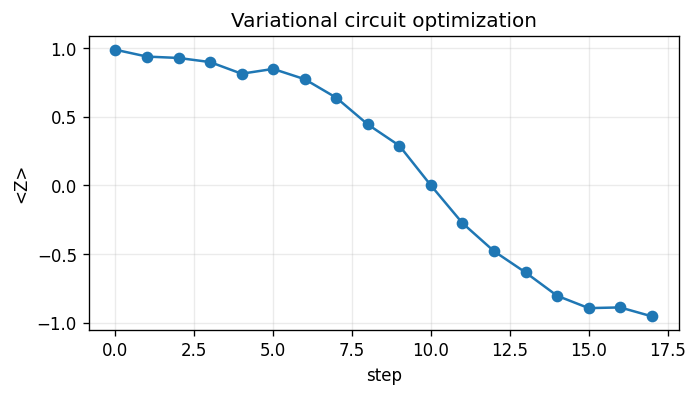

In [2]:
def build_ansatz(theta):
    c = Circuit()
    c.ry(0, float(theta))
    c.measure(0)
    return c

def z_expectation(theta):
    counts = OriginIR_Simulator().simulate_shots(build_ansatz(theta).originir, shots=400)
    total = sum(counts.values()) or 1
    p0 = counts.get(0, 0) / total
    p1 = counts.get(1, 0) / total
    return p0 - p1

theta = 0.2
history = []
for step in range(18):
    value = z_expectation(theta)
    plus = z_expectation(theta + math.pi / 2)
    minus = z_expectation(theta - math.pi / 2)
    grad = 0.5 * (plus - minus)
    history.append((step, theta, value, grad))
    theta -= 0.25 * grad

for row in history[::4]:
    print("step=%02d theta=%.3f <Z>=%.3f grad=%.3f" % row)
print("final theta:", round(theta, 4))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot([r[0] for r in history], [r[2] for r in history], marker="o")
ax.set_xlabel("step")
ax.set_ylabel("<Z>")
ax.set_title("Variational circuit optimization")
ax.grid(alpha=0.25)
fig.tight_layout()
